In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv('/home/lolkek3310/python/Подготовка Гомель/Кластеризация/Набор данных Wine для кластеризации/wine-clustering.csv')
# print(df.info())
print(df.isnull().sum())

Alcohol                 0
Malic_Acid              0
Ash                     0
Ash_Alcanity            0
Magnesium               0
Total_Phenols           0
Flavanoids              0
Nonflavanoid_Phenols    0
Proanthocyanins         0
Color_Intensity         0
Hue                     0
OD280                   0
Proline                 0
dtype: int64


In [3]:
scalern = StandardScaler()
scalern.fit(df)
df_scaler = scalern.transform(df)
print(df_scaler[0])

[ 1.51861254 -0.5622498   0.23205254 -1.16959318  1.91390522  0.80899739
  1.03481896 -0.65956311  1.22488398  0.25171685  0.36217728  1.84791957
  1.01300893]


In [4]:
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaler)
print(df_pca.shape)

(178, 2)


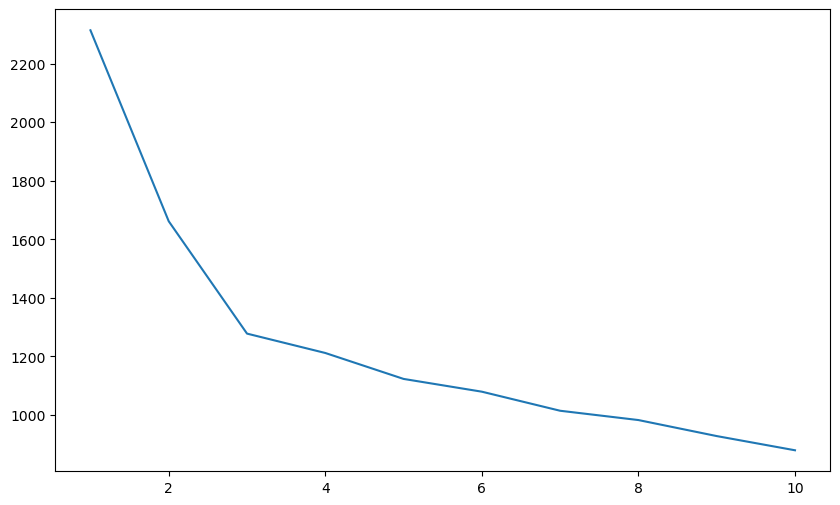

In [8]:

lst_for_cluster=[]

for i in range(1,11):
    kmeans = KMeans(n_clusters=i,init='k-means++', random_state=42)
    kmeans.fit(df_scaler)
    lst_for_cluster.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1,11),lst_for_cluster)
plt.show()

In [6]:
kmeans = KMeans(n_clusters=3,init='k-means++',random_state=42)
cluster = kmeans.fit_predict(df_pca)
df["Cluster"]  = cluster
df

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,Cluster
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,2
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,2
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,2
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,2
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740,1
174,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750,1
175,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835,1
176,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840,1


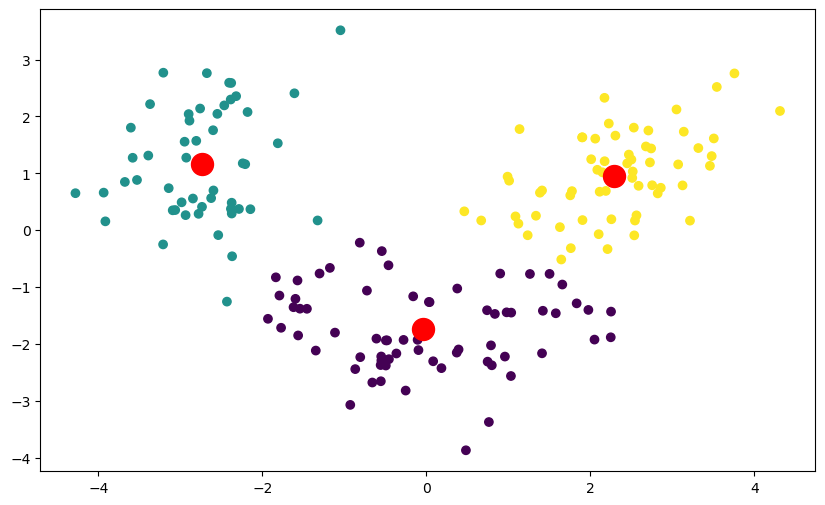

In [7]:
plt.figure(figsize=(10,6))
plt.scatter(x=df_pca[:,0], y=df_pca[:,1],c=df['Cluster'])


plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], c ='red', s=250,)
plt.show()